# Task 1 — Classification Algorithms
**Course:** Machine Learning & Deep Learning  
**Points:** 10/60  
**School of Artificial Intelligence and Data Science**

---

## Overview
In this task, we explore and compare six established classification algorithms, understand their theoretical foundations, and analyze their strengths and weaknesses.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification, make_circles


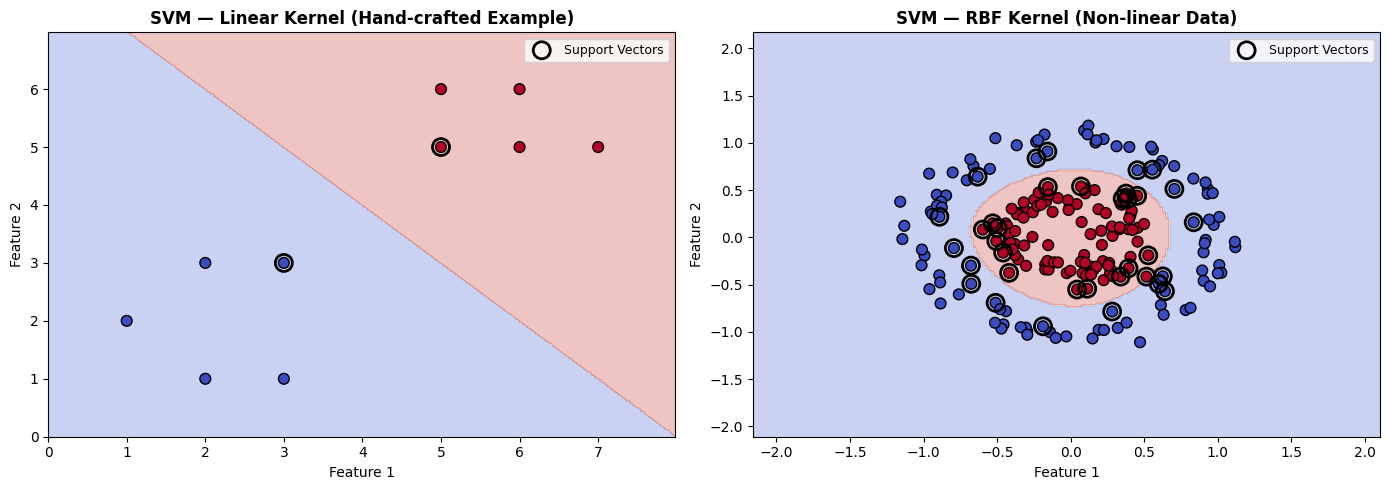

Figure saved.


In [8]:

# ─── Hand-crafted 2D example ───────────────────────────────────────────────
np.random.seed(42)
X_simple = np.array([[1,2],[2,3],[3,3],[2,1],[3,1],   # Class 0
                      [5,5],[6,5],[5,6],[6,6],[7,5]])   # Class 1
y_simple = np.array([0,0,0,0,0, 1,1,1,1,1])

# ─── SVM with linear kernel ────────────────────────────────────────────
svm_lin = SVC(kernel='linear', C=1.0)
svm_lin.fit(X_simple, y_simple)

# ─── RBF kernel on non-linear data ────────────────────────────────────────
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_circles, y_circles)

def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=60)
    if hasattr(model, 'support_vectors_'):
        ax.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
                   s=150, facecolors='none', edgecolors='black', linewidths=2, label='Support Vectors')
        ax.legend(fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(axes[0], svm_lin, X_simple, y_simple, 'SVM — Linear Kernel (Hand-crafted Example)')
plot_decision_boundary(axes[1], svm_rbf, X_circles, y_circles, 'SVM — RBF Kernel (Non-linear Data)')
plt.tight_layout()
plt.savefig('../results/T1_SVM_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [9]:
# ─── Manual calculation example ────────────────────────────────────────────
print('=== Manual SVM Calculation Example ===')
print()
print('Dataset (2D, linearly separable):')
print('Class +1: (1,2), (2,3), (3,3)')
print('Class -1: (2,1), (3,1), (1,0)')
print()
print('Step 1: Find support vectors (points closest to boundary)')
print('Step 2: Compute margin = 2 / ||w||')
print('Step 3: Maximize margin → minimize ||w||²/2')
print()

X_manual = np.array([[1,2],[2,3],[3,3],[2,1],[3,1],[1,0]], dtype=float)
y_manual = np.array([1,1,1,-1,-1,-1])

svm_manual = SVC(kernel='linear', C=1e6)  # Hard margin
svm_manual.fit(X_manual, y_manual)

w = svm_manual.coef_[0]
b = svm_manual.intercept_[0]
margin = 2 / np.linalg.norm(w)

print(f'Learned weights:   w = [{w[0]:.4f}, {w[1]:.4f}]')
print(f'Learned bias:      b = {b:.4f}')
print(f'Margin:            {margin:.4f}')
print(f'Support vectors:\n{svm_manual.support_vectors_}')
print()
print('Overfitting: high C → hard margin → memorizes training data')
print('Underfitting: low C → soft margin → may misclassify training points')

=== Manual SVM Calculation Example ===

Dataset (2D, linearly separable):
Class +1: (1,2), (2,3), (3,3)
Class -1: (2,1), (3,1), (1,0)

Step 1: Find support vectors (points closest to boundary)
Step 2: Compute margin = 2 / ||w||
Step 3: Maximize margin → minimize ||w||²/2

Learned weights:   w = [-0.6668, 1.3336]
Learned bias:      b = -1.0002
Margin:            1.3414
Support vectors:
[[2. 1.]
 [1. 2.]
 [3. 3.]]

Overfitting: high C → hard margin → memorizes training data
Underfitting: low C → soft margin → may misclassify training points


## Summary

| Algorithm | Best For | Key Weakness |
|---|---|---|
| k-NN | Small datasets, non-linear | Slow inference, scale-sensitive |
| Decision Tree | Interpretability | Overfitting |
| Random Forest | General purpose, robust | Memory, less interpretable |
| SVM | High-dim, small-medium data | Slow on large n |
| Logistic Regression | Linear problems, baseline | Linear boundary only |
| Naive Bayes | Text, fast baseline | Independence assumption |

**Conclusion:** No single algorithm dominates all scenarios. The choice depends on dataset size, dimensionality, interpretability requirements, and computational budget.